In [13]:
from parselog import *
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import multiprocessing
from collections import defaultdict
import sys

In [14]:
def calcAccuracy(
    benchmark,
    run="org_setup", 
    prefetcherLocation="cap_ptr-l1",
    silent = True,
):
    pickleFile = f"results/pickles/accuracyData/{run}-{prefetcherLocation}-{benchmark.lower()}.pickle"
    if not os.path.isfile(pickleFile):

        lp = LogParser(
            log=f"results/{run}-{prefetcherLocation}/{benchmark.lower()}/sim_stdout.gz",
            lineTypesToPrune=[None, NonRVFILine], 
            # If a timestamped line matches, then either RVFILine or NonRVFILine will match
            lineTypesToError=[TimestampedLine],
            RootLogLine=TimestampedLine,
            maxLines=None,
            silent=silent
            #startWhen=(lambda ll: isinstance(ll, RVFILine) and ll.rvfi >= 10000),
        )

        sys.stdout.write(f"{benchmark}: {lp.totals[CRqCreationLine]["prefetchMiss"]} prefetches\n")
        sys.stdout.flush()
        groupSize = max(50, int(lp.totals[CRqCreationLine]["prefetchMiss"] / 500))
        useful = 0
        total = 0
        accuracies = {}

        for ll in lp.logLines:
            if isinstance(ll, CRqCreationLine) and ll.isPrefetch and ll.miss:
                total += 1
                if not ll.isNeverAccessed or ll.isNeverAccessedBecausePerms:
                    useful += 1
                if total == groupSize:
                    accuracies[ll.timestamp] = useful/total
                    useful = 0
                    total = 0
        if total > 20:
            accuracies[lp.logLines[-1]] = useful/total

        with open(pickleFile, "wb") as fp:
            pickle.dump(accuracies, fp)



def plotAccuracy(
    benchmark,
    run="org_setup", 
    prefetcherLocation="cap_ptr-l1",
    numGroups=200
):
    accuracies = {}

    pickleFile = f"results/pickles/accuracyData/{run}-{prefetcherLocation}-{benchmark.lower()}.pickle"
    print(pickleFile)
    assert(os.path.isfile(pickleFile))
    with open(pickleFile, "rb") as fp:
        accuracies = pickle.load(fp)
        accuracies = {
            k.timestamp if isinstance(k, LogLine) else k: v
            for (k, v) in accuracies.items()
        }

    print(accuracies)

    fig, ax = plt.subplots(1, 1, dpi=150)
    earliestTimeFraction = 1
    if len(accuracies) < 50: 
        return
    groupSize = max(1, int(len(accuracies)/numGroups))
    grouped = {}
    accumulatedConfs = 0
    groupStartTime = None
    for i, (t, acc) in enumerate(accuracies.items()):
        if not groupStartTime:
            groupStartTime = t
        accumulatedConfs += acc
        if (i+1) % groupSize == 0:
            grouped[(t+groupStartTime)/2] = accumulatedConfs/groupSize
            accumulatedConfs = 0
            groupStartTime = None
    groupedItems = list(grouped.items())
    chunked = [{groupedItems[0][0]: groupedItems[0][1]}]
    totalTime = groupedItems[-1][0]-groupedItems[0][0]
    lastTime = groupedItems[0][0]
    earliestTimeFraction = min(groupedItems[0][0]/totalTime, earliestTimeFraction)
    for t, acc in groupedItems[1:]:
        if (t-lastTime)/totalTime > 0.05:
            chunked.append({})
        chunked[-1][t] = acc
        lastTime = t
    color = None
    for c in chunked:
        line, = ax.plot(
            list(t / 1000000. for t in c.keys()), 
            list(c.values()), 
            marker="", 
            linestyle="-", 
            alpha=0.5, 
            linewidth=1.0,
            color=color
        )
        color = line.get_color()
    if earliestTimeFraction < 0.2:
        ax.set_xlim(0)
    else:
        xmin, xmax = ax.get_xlim()
        ax.margins(x=0.09)
        ax.set_xlim(xmax=xmax)
        dx=0.003
        dy=0.07
        x=0.02
        ax.plot((x-dx, x+dx), (-dy, dy), transform=ax.transAxes, color='k', clip_on=False)        # top-left diagonal
        ax.plot((x+3*dx, x+5*dx), (-dy, +dy), transform=ax.transAxes, color='k', clip_on=False)  # top-right diagonal
        #if ax.transAxes.inverted().transform(ax.transData.transform((ax.get_xticks()[0] , 0)))[0] < x*2:
        #    ax.set_xticks(ax.get_xticks()[1:])
    fig.suptitle(benchmark)
    #fig.legend()
    #fig.tight_layout()
    fig.show()

In [15]:
BENCHMARKS = [
    "BH",
    "Bisort",
    #"dijkstra",
    #"dijkstra_capchain",
    "EM3D",
    "Health",
    "Patricia",
    "Perimeter",
    "Power",
    "Treeadd",
    "Treeadd_frag",
    "TSP",
]

with multiprocessing.Pool(processes=16) as pool:
    pool.map(calcAccuracy, BENCHMARKS)

results/pickles/accuracyData/org_setup-cap_ptr-l1-bh.pickle
{917406: 0.58, 947811: 0.54, 971542: 0.58, 1022961: 0.5, 1068572: 0.74, 1108197: 0.84, 1150380: 0.74, 1198678: 0.84, 1228269: 0.76, 1257527: 0.62, 1312706: 0.82, 1349576: 0.76, 1382205: 0.72, 1412633: 0.8, 1451660: 0.76, 1507740: 0.76, 1554798: 0.7, 1599524: 0.8, 1640767: 0.74, 1684660: 0.78, 1727351: 0.78, 1771642: 0.78, 1837988: 0.9, 1892043: 0.74, 1933410: 0.84, 1983769: 0.82, 2025712: 0.8, 2078858: 0.8, 2133212: 0.88, 2172587: 0.78, 2212447: 0.74, 2252230: 0.82, 2296371: 0.86, 2353173: 0.72, 2393262: 0.8, 2422313: 0.8, 2471763: 0.86, 2540429: 0.86, 2596762: 0.9, 2640648: 0.86, 2673818: 0.68, 2714008: 0.88, 2751231: 0.82, 2778055: 0.82, 2822477: 0.78, 2859227: 0.72, 2896973: 0.84, 2933245: 0.76, 2971563: 0.82, 2995807: 0.7, 3029845: 0.74, 3069374: 0.76, 3102122: 0.7, 3138679: 0.84, 3169151: 0.68, 3196211: 0.64, 3228875: 0.68, 3260853: 0.72, 3299682: 0.78, 3339964: 0.78, 3374399: 0.88, 3403534: 0.74, 3438610: 0.8, 3476822: 0

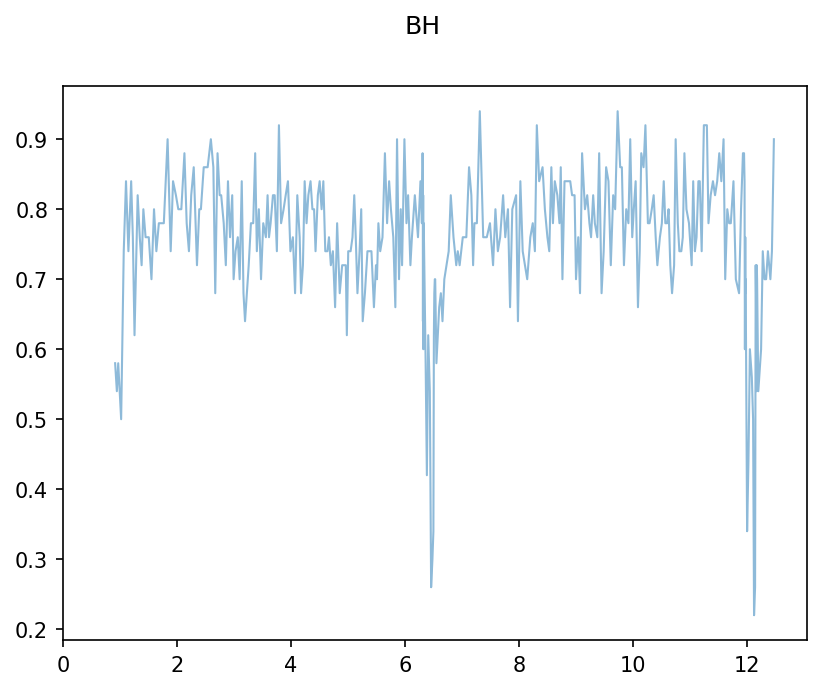

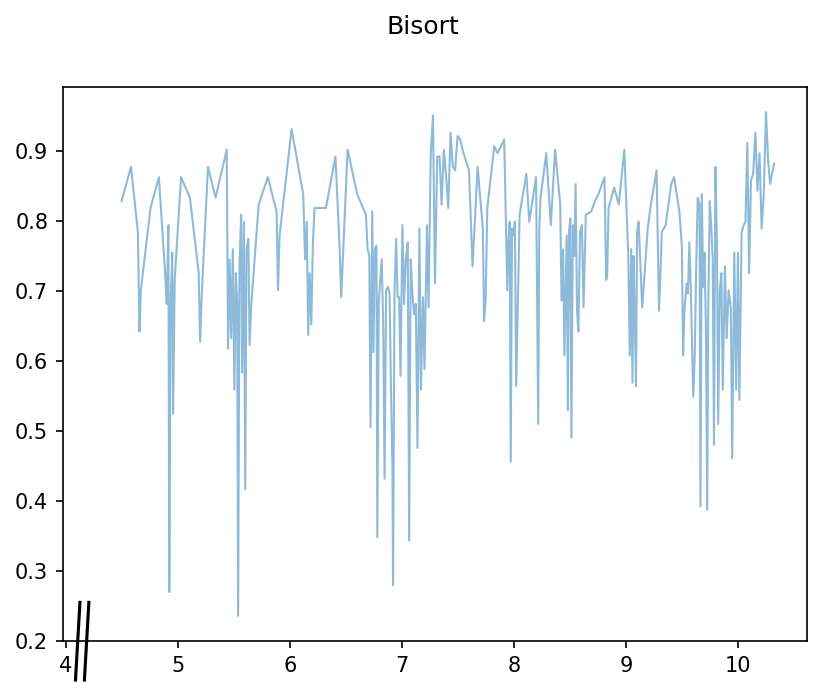

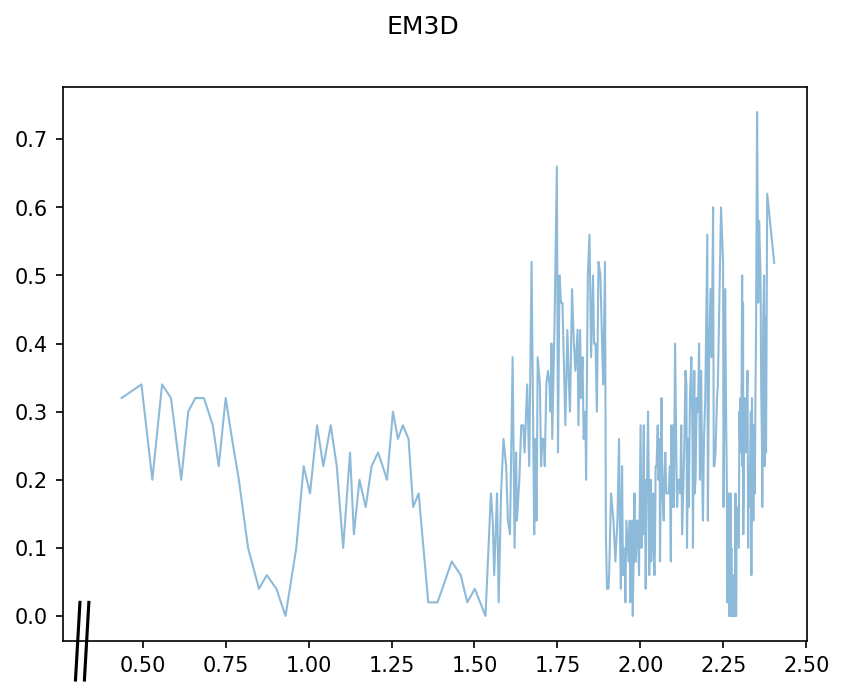

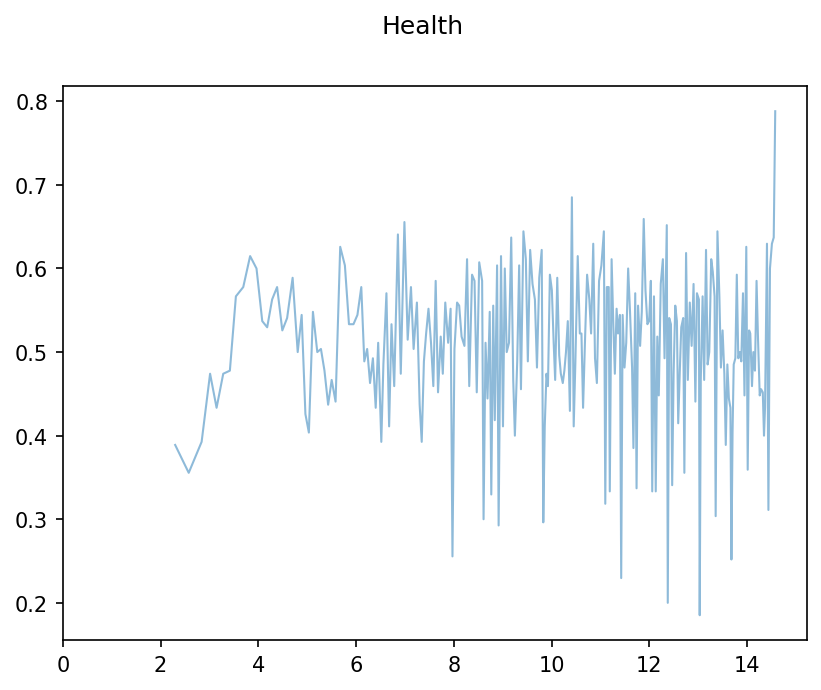

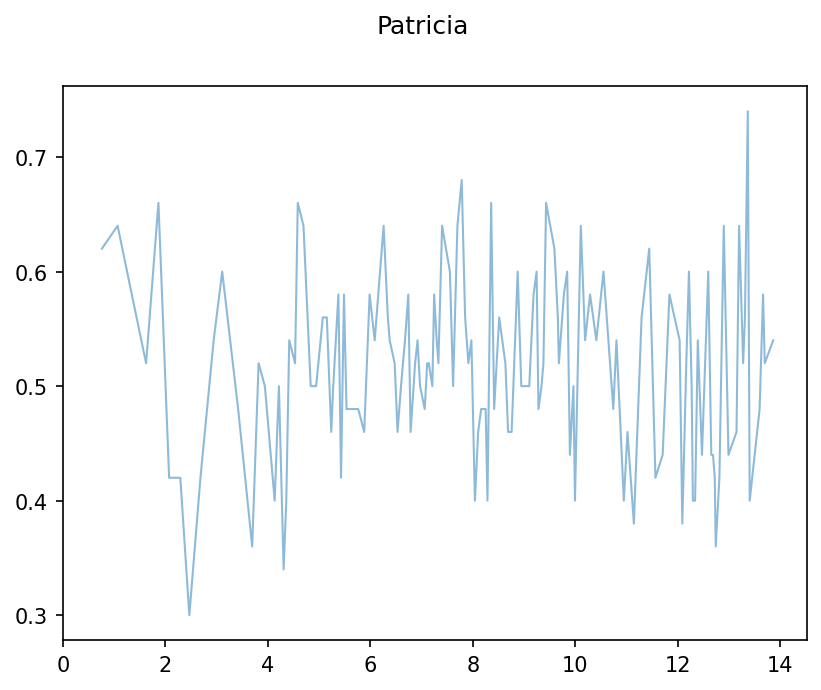

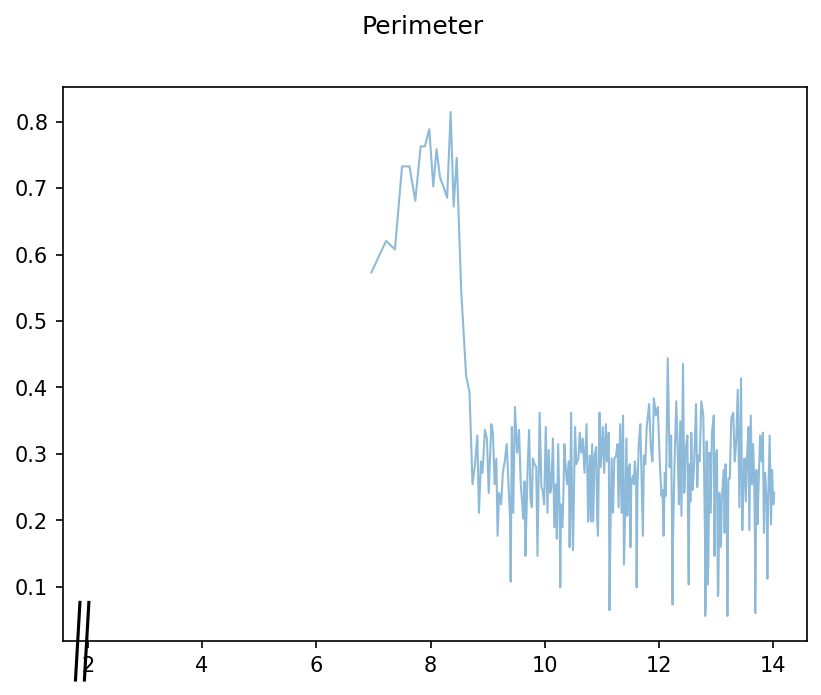

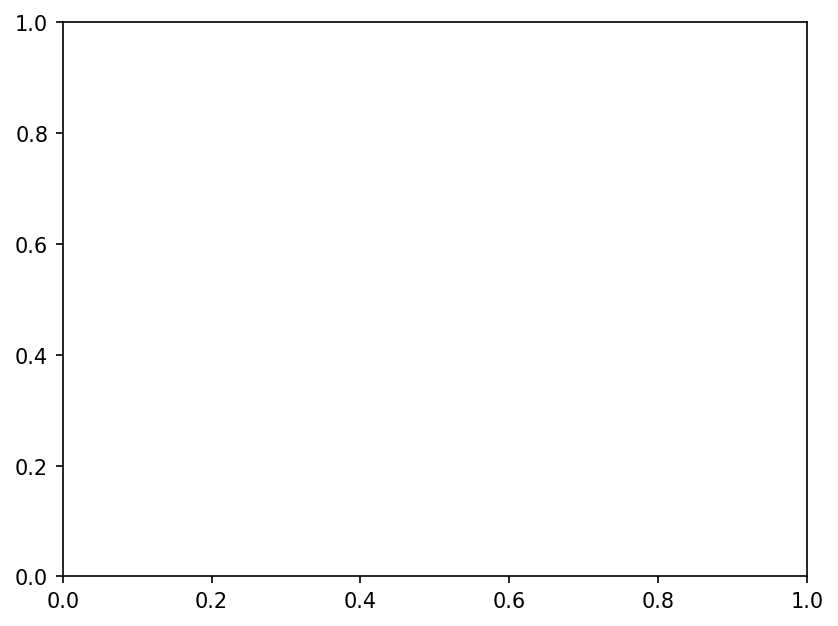

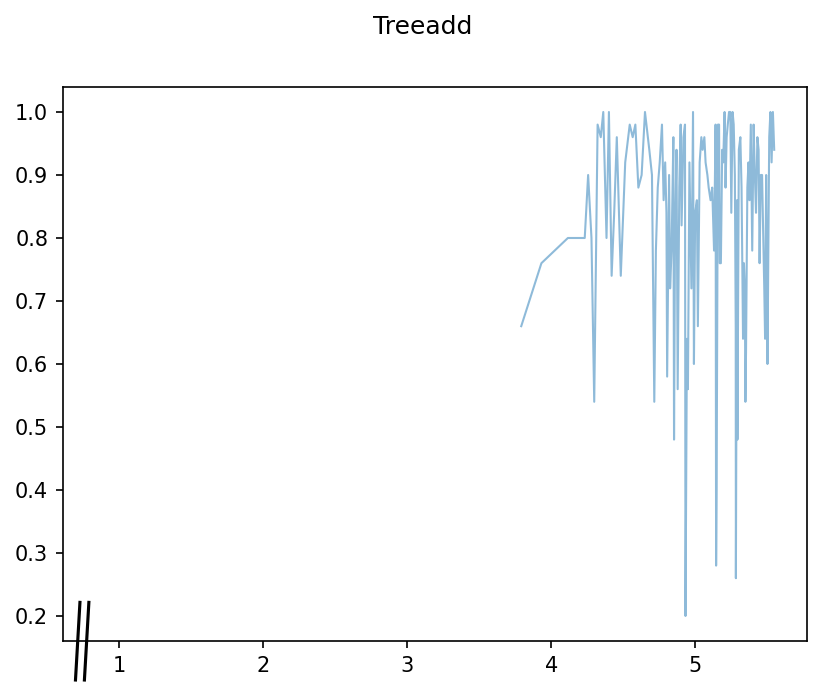

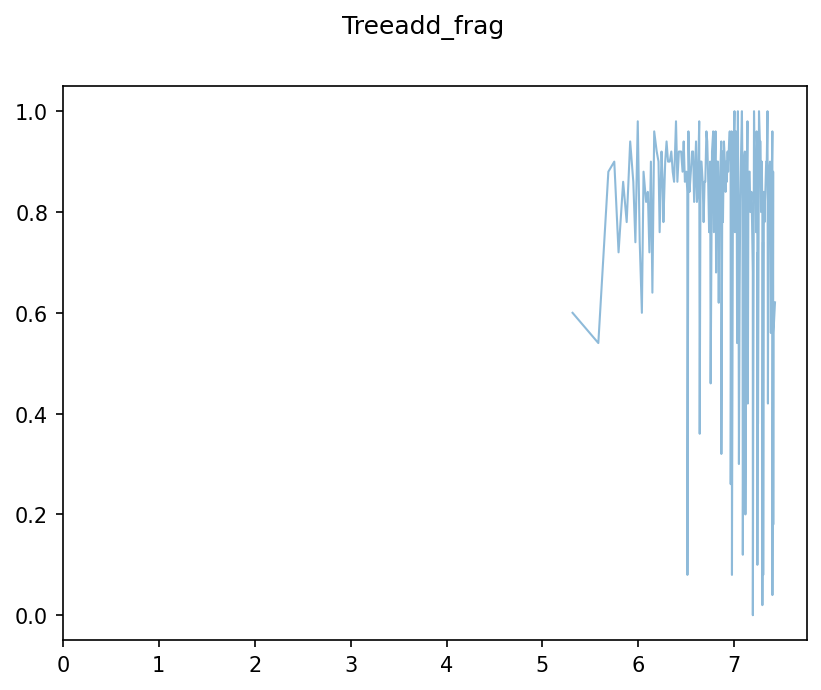

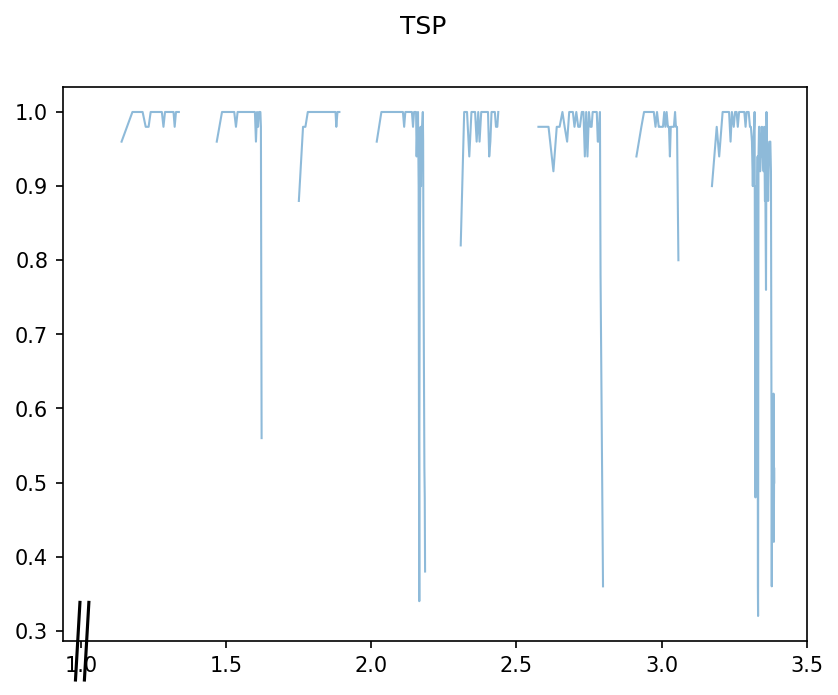

In [16]:
for benchmark in BENCHMARKS:
    plotAccuracy(benchmark)